In [1]:
pip install PyPDF2 nltk matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:

import nltk
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
import os
import PyPDF2
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
import string

# Download resources (only needed once)
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Set up sentiment analyzer
sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

# Folder path
folder_path = r"C:\Users\ADMIN\Desktop\Finance_Analytics\Earning Calls"

def extract_text_from_pdf(pdf_path):
    """Extract text from a PDF file"""
    text = ""
    with open(pdf_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            text += page.extract_text() or ""
    return text

def clean_and_tokenize(text):
    """Clean text and tokenize"""
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

def analyze_text(text):
    """Perform text analysis"""
    tokens = clean_and_tokenize(text)
    word_count = len(tokens)
    most_common = Counter(tokens).most_common(10)
    sentiment = sia.polarity_scores(text)
    return word_count, most_common, sentiment

def main():
    for filename in os.listdir(folder_path):
        if filename.endswith(".pdf"):
            full_path = os.path.join(folder_path, filename)
            print(f"\nAnalyzing: {filename}")
            text = extract_text_from_pdf(full_path)
            word_count, common_words, sentiment = analyze_text(text)
            print(f"  Word Count: {word_count}")
            print(f"  Most Common Words: {common_words}")
            print(f"  Sentiment Scores: {sentiment}")

if __name__ == "__main__":
    main()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Analyzing: 1.ABNB - Q4 2023.pdf
  Word Count: 6475
  Most Common Words: [('airbnb', 103), ('inc', 67), ('think', 62), ('year', 54), ('growth', 52), ('going', 51), ('call', 41), ('llc', 41), ('one', 40), ('us', 39)]
  Sentiment Scores: {'neg': 0.018, 'neu': 0.835, 'pos': 0.147, 'compound': 1.0}

Analyzing: 2.ABNB - Q1 2024 .pdf
  Word Count: 6641
  Most Common Words: [('airbnb', 100), ('year', 70), ('think', 69), ('inc', 65), ('would', 59), ('really', 58), ('2024', 53), ('llc', 53), ('analyst', 44), ('people', 44)]
  Sentiment Scores: {'neg': 0.02, 'neu': 0.844, 'pos': 0.136, 'compound': 1.0}

Analyzing: 3.ABNB - Q2 2024.pdf
  Word Count: 6452
  Most Common Words: [('airbnb', 104), ('think', 69), ('inc', 56), ('like', 50), ('one', 50), ('2024', 45), ('year', 44), ('going', 44), ('question', 44), ('terms', 43)]
  Sentiment Scores: {'neg': 0.019, 'neu': 0.859, 'pos': 0.122, 'compound': 1.0}

Analyzing: 4. ABNB - Q3 2024 .pdf
  Word Count: 6098
  Most Common Words: [('airbnb', 114), ('thi

In [4]:
import os
import PyPDF2
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
import string

# Download NLTK data if not already downloaded
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Define folder path
folder_path = r"C:\Users\ADMIN\Desktop\Finance_Analytics\Earning Calls"

# Initialize stopwords and sentiment analyzer
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

# Define section keywords
management_keywords = ["management discussion", "management discussion and analysis", "md&a"]
qa_keywords = ["q&a", "questions and answers", "question-and-answer session", "analyst questions"]

def extract_text_from_pdf(pdf_path):
    """Extract full text from a PDF file"""
    text = ""
    with open(pdf_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text

def extract_section(text, start_keywords, end_keywords=None):
    """Extract text between start and end keywords"""
    text_lower = text.lower()
    for start_kw in start_keywords:
        start_index = text_lower.find(start_kw)
        if start_index != -1:
            end_index = len(text)
            if end_keywords:
                for end_kw in end_keywords:
                    temp_index = text_lower.find(end_kw, start_index + len(start_kw))
                    if temp_index != -1 and temp_index < end_index:
                        end_index = temp_index
            return text[start_index:end_index].strip()
    return ""

def clean_and_tokenize(text):
    """Lowercase, remove punctuation, remove stopwords, and tokenize"""
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

def analyze_text(text):
    """Run basic text analysis: word count, top words, sentiment"""
    tokens = clean_and_tokenize(text)
    word_count = len(tokens)
    most_common = Counter(tokens).most_common(10)
    sentiment = sia.polarity_scores(text)
    return word_count, most_common, sentiment

def analyze_file(pdf_path):
    """Extract and analyze specific sections from a PDF file"""
    full_text = extract_text_from_pdf(pdf_path)
    
    # Extract sections
    management_section = extract_section(full_text, management_keywords, qa_keywords)
    qa_section = extract_section(full_text, qa_keywords)

    # Analyze each section
    print(f"\n🔎 Analyzing: {os.path.basename(pdf_path)}")

    print("\n📌 Management Discussion:")
    if management_section:
        wc, top_words, sentiment = analyze_text(management_section)
        print(f"  Word Count: {wc}")
        print(f"  Top Words: {top_words}")
        print(f"  Sentiment: {sentiment}")
    else:
        print("  Section not found.")

    print("\n📌 Q&A Section:")
    if qa_section:
        wc, top_words, sentiment = analyze_text(qa_section)
        print(f"  Word Count: {wc}")
        print(f"  Top Words: {top_words}")
        print(f"  Sentiment: {sentiment}")
    else:
        print("  Section not found.")

def main():
    for file in os.listdir(folder_path):
        if file.lower().endswith(".pdf"):
            pdf_path = os.path.join(folder_path, file)
            analyze_file(pdf_path)

if __name__ == "__main__":
    main()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



🔎 Analyzing: 1.ABNB - Q4 2023.pdf

📌 Management Discussion:
  Word Count: 99
  Top Words: [('call', 7), ('airbnbs', 4), ('investor', 4), ('relations', 4), ('section', 3), ('fourth', 3), ('quarter', 3), ('2023', 3), ('today', 3), ('good', 2)]
  Sentiment: {'neg': 0.0, 'neu': 0.889, 'pos': 0.111, 'compound': 0.9538}

📌 Q&A Section:
  Word Count: 6160
  Top Words: [('airbnb', 94), ('think', 62), ('inc', 54), ('year', 54), ('growth', 52), ('going', 51), ('one', 40), ('us', 38), ('business', 36), ('supply', 35)]
  Sentiment: {'neg': 0.019, 'neu': 0.832, 'pos': 0.15, 'compound': 1.0}

🔎 Analyzing: 2.ABNB - Q1 2024 .pdf

📌 Management Discussion:
  Word Count: 100
  Top Words: [('call', 7), ('airbnbs', 5), ('investor', 4), ('section', 3), ('first', 3), ('quarter', 3), ('2024', 3), ('relations', 3), ('today', 3), ('good', 2)]
  Sentiment: {'neg': 0.0, 'neu': 0.89, 'pos': 0.11, 'compound': 0.9538}

📌 Q&A Section:
  Word Count: 6353
  Top Words: [('airbnb', 93), ('year', 70), ('think', 69), ('wo

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Device set to use cpu


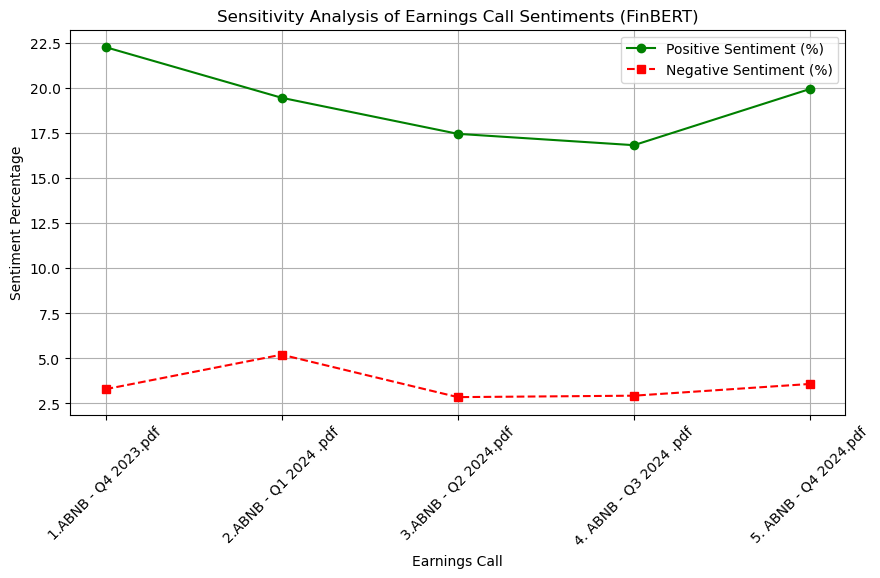

            Earnings Call  Positive  Neutral  Negative  Total Sentences  \
0    1.ABNB - Q4 2023.pdf       142      475        21              638   
1   2.ABNB - Q1 2024 .pdf       127      492        34              653   
2    3.ABNB - Q2 2024.pdf       104      475        17              596   
3  4. ABNB - Q3 2024 .pdf       109      520        19              648   
4   5. ABNB - Q4 2024.pdf       128      491        23              642   

   Positive %  Negative %  
0   22.257053    3.291536  
1   19.448698    5.206738  
2   17.449664    2.852349  
3   16.820988    2.932099  
4   19.937695    3.582555  


In [5]:
import os
import PyPDF2
import nltk
from nltk.tokenize import sent_tokenize
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, pipeline

# Download NLTK tokenizer (if not already installed)
nltk.download("punkt")

# Load FinBERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
sentiment_pipeline = pipeline("text-classification", model="ProsusAI/finbert")

# Folder containing earnings call PDFs
folder_path = r"C:\Users\ADMIN\Desktop\Finance_Analytics\Earning Calls"

# Function to extract text from a PDF file
def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, "rb") as pdf_file:
        reader = PyPDF2.PdfReader(pdf_file)
        for page in reader.pages:
            text += page.extract_text() + "\n"
    return text

# Function to process sentences safely (truncate if >512 tokens)
def analyze_text_with_truncation(text):
    tokenized_text = tokenizer.encode(text, truncation=True, max_length=512, return_tensors="pt")
    sentiment = sentiment_pipeline(text[:512])[0]  # Only send 512 chars to avoid token mismatch
    return sentiment

# Process each PDF in the folder
sentiment_results = []
for filename in os.listdir(folder_path):
    if filename.endswith(".pdf"):
        file_path = os.path.join(folder_path, filename)
        
        # Extract text from PDF
        transcript_text = extract_text_from_pdf(file_path)
        sentences = sent_tokenize(transcript_text)

        # Run sentiment analysis with truncation
        sentiments = [analyze_text_with_truncation(sentence) for sentence in sentences]

        # Count sentiment distribution
        sentiment_counts = {
            "positive": sum(1 for s in sentiments if s["label"] == "positive"),
            "neutral": sum(1 for s in sentiments if s["label"] == "neutral"),
            "negative": sum(1 for s in sentiments if s["label"] == "negative")
        }
        
        # Store results
        sentiment_results.append({
            "Earnings Call": filename,
            "Positive": sentiment_counts["positive"],
            "Neutral": sentiment_counts["neutral"],
            "Negative": sentiment_counts["negative"],
            "Total Sentences": len(sentiments),
            "Positive %": sentiment_counts["positive"] / len(sentiments) * 100,
            "Negative %": sentiment_counts["negative"] / len(sentiments) * 100
        })

# Convert results to DataFrame
df_results = pd.DataFrame(sentiment_results)

# 🎨 Plot sensitivity analysis (Positive vs. Negative %)
plt.figure(figsize=(10, 5))
plt.plot(df_results["Earnings Call"], df_results["Positive %"], marker="o", linestyle="-", label="Positive Sentiment (%)", color="green")
plt.plot(df_results["Earnings Call"], df_results["Negative %"], marker="s", linestyle="--", label="Negative Sentiment (%)", color="red")
plt.xlabel("Earnings Call")
plt.ylabel("Sentiment Percentage")
plt.title("Sensitivity Analysis of Earnings Call Sentiments (FinBERT)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# 📊 Print summarized sensitivity results
print(df_results)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Date
2024-05-07         NaN
2024-05-08   -0.011952
2024-05-09   -0.068714
2024-05-10   -0.004964
2024-05-13    0.019204
2024-05-14   -0.016295
2024-05-15   -0.006135
2024-05-16    0.009534
2024-05-17   -0.010395
2024-05-20    0.004874
2024-05-21   -0.015509
2024-05-22   -0.009646
2024-05-23   -0.011702
2024-05-24    0.024319
2024-05-28    0.017581
2024-05-29   -0.002721
2024-05-30   -0.007435
2024-05-31   -0.004055
2024-06-03    0.009108
2024-06-04    0.005675
2024-06-05   -0.008839
2024-06-06    0.008369
2024-06-07   -0.002313
2024-06-10    0.009614
2024-06-11   -0.002161
2024-06-12    0.010626
2024-06-13   -0.021564
2024-06-14   -0.000890
2024-06-17    0.024183
2024-06-18   -0.014783
2024-06-20    0.004006
2024-06-21    0.011428
2024-06-24   -0.007889
2024-06-25    0.016982
2024-06-26   -0.006030
2024-06-27    0.010733
2024-06-28    0.000132
2024-07-01    0.000000
2024-07-02    0.017872
2024-07-03   -0.010432
2024-07-05   -0.001506
2024-07-08   -0.003541
2024-07-09    0.003224
2024-0

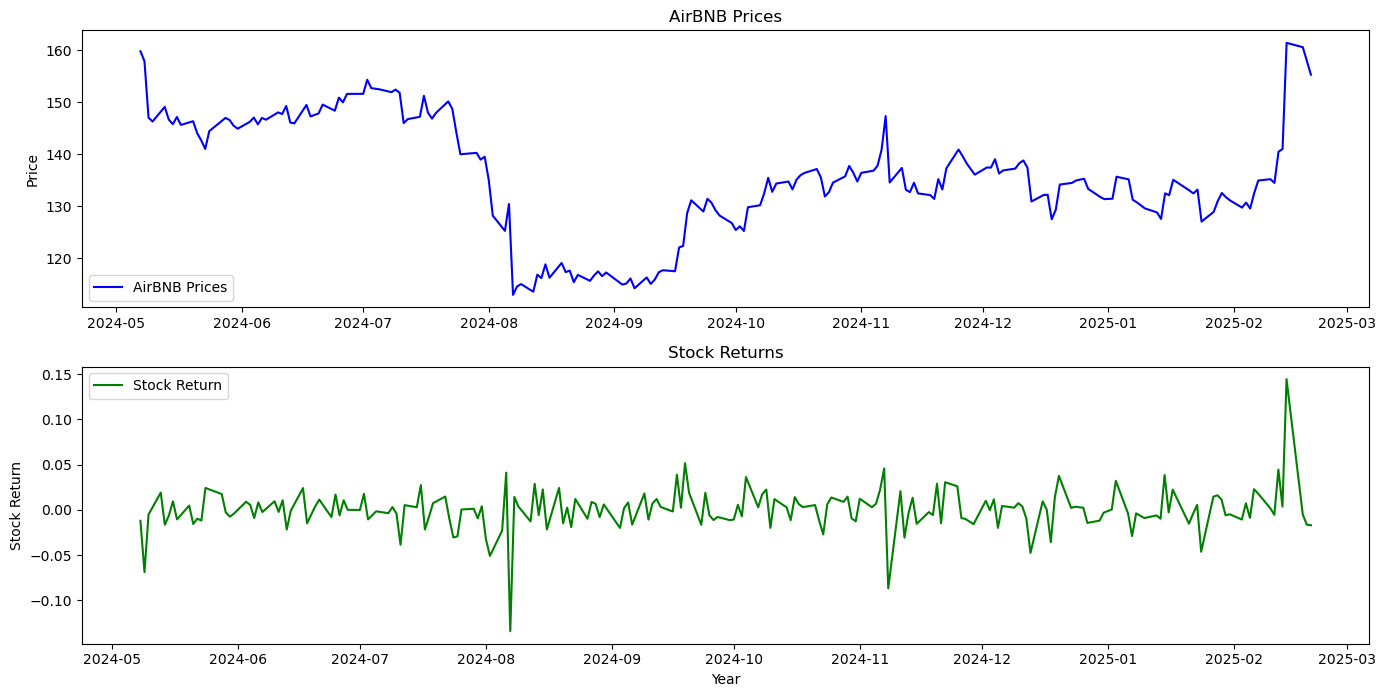

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Fetch AirBNB data from Yahoo Finance
df = yf.download("ABNB", start="2024-05-07", end="2025-02-21")

# Calculate daily returns and annualized volatility
df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(window=252).std() * np.sqrt(252)
 
pd.set_option('display.max_rows', None)

# Now print or display the full Series
print(df["Returns"])

# Plot the AirBnb prices
plt.figure(figsize=(14, 10))
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Close'], label='AirBNB Prices', color='blue')
plt.title('AirBNB Prices')
plt.ylabel('Price')
plt.legend()


# Plot the stock return
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Returns'], label='Stock Return', color='Green')
plt.title('Stock Returns')
plt.ylabel('Stock Return')
plt.xlabel('Year')
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import re

# -- 1. Retrieve just the 'Close' column from yfinance as a single-level DataFrame
df_stock = yf.download("ABNB", start="2024-01-01", end="2025-03-01")[['Close']].dropna()

# Calculate daily returns and annualized volatility on this single-level DataFrame
df_stock['Returns'] = df_stock['Close'].pct_change()
df_stock['Volatility'] = df_stock['Returns'].rolling(window=252).std() * np.sqrt(252)

# -- 2. Recompute stock movement for your earnings call dates --
input_dates = ['2024-02-13', '2024-05-08', '2024-08-06', '2024-11-07', '2025-02-13']
stock_movement = []
for date_str in input_dates:
    date = pd.to_datetime(date_str)
    try:
        date_idx = df_stock.index.get_loc(date)
        
        # Force close_price to be a scalar
        close_price = df_stock.loc[date, 'Close']
        if isinstance(close_price, pd.Series):
            close_price = close_price.iloc[0]
        
        row = {'Date': date.strftime('%Y-%m-%d'), 'Close Price': close_price}
        
        # Calculate returns for offsets: 1D=1 row, 3D=3 rows, 5D=5 rows, 1W=7 rows.
        for label, offset in [('1D', 1), ('3D', 3), ('5D', 5), ('1W', 7)]:
            if (date_idx + offset) < len(df_stock):
                future_close = df_stock['Close'].iloc[date_idx + offset]
                if isinstance(future_close, pd.Series):
                    future_close = future_close.iloc[0]
                row[f'{label} Return'] = (future_close - close_price) / close_price
            else:
                row[f'{label} Return'] = np.nan
        
        stock_movement.append(row)
    
    except Exception as e:
        print(f"Error processing date {date_str}: {e}")

movement_df = pd.DataFrame(stock_movement)

# -- 3. Map each date to a Quarter label for merging --
quarter_map = {
    '2024-02-13': 'Q4 2023',
    '2024-05-08': 'Q1 2024',
    '2024-08-06': 'Q2 2024',
    '2024-11-07': 'Q3 2024',
    '2025-02-13': 'Q4 2024'
}
movement_df['Quarter'] = movement_df['Date'].map(quarter_map)

# -- 4. Use your existing sentiment DataFrame (df_results) and add a 'Quarter' column --
def extract_quarter_from_filename(filename):
    match = re.search(r'(Q[1-4]\s*\d{4})', filename.upper())
    return match.group(1).strip() if match else None

df_results['Quarter'] = df_results['Earnings Call'].apply(extract_quarter_from_filename)

# -- 5. Merge the sentiment and stock movement DataFrames on 'Quarter' --
merged_df = pd.merge(df_results, movement_df, on='Quarter', how='inner').reset_index(drop=True)

# Compute the Positive/Negative ratio.
merged_df['Pos/Neg Ratio'] = merged_df.apply(lambda row: row['Positive'] / row['Negative']
                                               if row['Negative'] > 0 else np.nan, axis=1)

# Select and order desired columns.
final_df = merged_df[['Quarter', 'Positive', 'Negative', 'Pos/Neg Ratio',
                        '1D Return', '3D Return', '5D Return', '1W Return']]

# -- 6. Sort the final DataFrame so that Q4 2023 is first.
def sort_quarter(q):
    # Extract quarter number and year from a string like "Q4 2023"
    m = re.search(r'Q([1-4])\s*(\d{4})', q)
    if m:
        quarter = int(m.group(1))
        year = int(m.group(2))
        return (year, quarter)
    else:
        return (9999, 0)

# Apply the custom key to the Quarter column.
final_df = final_df.sort_values(by='Quarter', key=lambda col: col.apply(sort_quarter)).reset_index(drop=True)

# -- 7. Convert return columns to percentage strings
for col in ['1D Return', '3D Return', '5D Return', '1W Return']:
    final_df[col] = final_df[col].apply(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "")

# Display only the final merged table.
display(final_df)


[*********************100%***********************]  1 of 1 completed


,Quarter,Positive,Negative,Pos/Neg Ratio,1D Return,3D Return,5D Return,1W Return
0,Q4 2023,142,21,6.761905,-1.74%,1.12%,-1.05%,1.22%
1,Q1 2024,127,34,3.735294,-6.87%,-5.55%,-7.66%,-7.75%
2,Q2 2024,104,17,6.117647,-13.38%,-11.80%,-10.40%,-8.88%
3,Q3 2024,109,19,5.736842,-8.66%,-9.62%,-8.69%,-10.30%
4,Q4 2024,128,23,5.565217,14.45%,12.01%,3.57%,0.36%
